In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("yahoo_stock.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (1825, 7)

Data Types:
 Date         datetime64[ns]
High                float64
Low                 float64
Open                float64
Close               float64
Volume              float64
Adj Close           float64
dtype: object

Missing Values:
 Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Adj Close    0
dtype: int64


In [2]:
df.describe()

,Date,High,Low,Open,Close,Volume,Adj Close
count,1825,1825.000000,1825.000000,1825.000000,1825.000000,1.825000e+03,1825.000000
mean,2018-05-23 00:00:00,2660.718673,2632.817580,2647.704751,2647.856284,3.869627e+09,2647.856284
min,2015-11-23 00:00:00,1847.000000,1810.099976,1833.400024,1829.079956,1.296540e+09,1829.079956
25%,2017-02-21 00:00:00,2348.350098,2322.250000,2341.979980,2328.949951,3.257950e+09,2328.949951
50%,2018-05-23 00:00:00,2696.250000,2667.840088,2685.489990,2683.340088,3.609740e+09,2683.340088
75%,2019-08-22 00:00:00,2930.790039,2900.709961,2913.860107,2917.520020,4.142850e+09,2917.520020
max,2020-11-20 00:00:00,3645.989990,3600.159912,3612.090088,3626.909912,9.044690e+09,3626.909912
std,NaN,409.680853,404.310068,407.169994,407.301177,1.087593e+09,407.301177


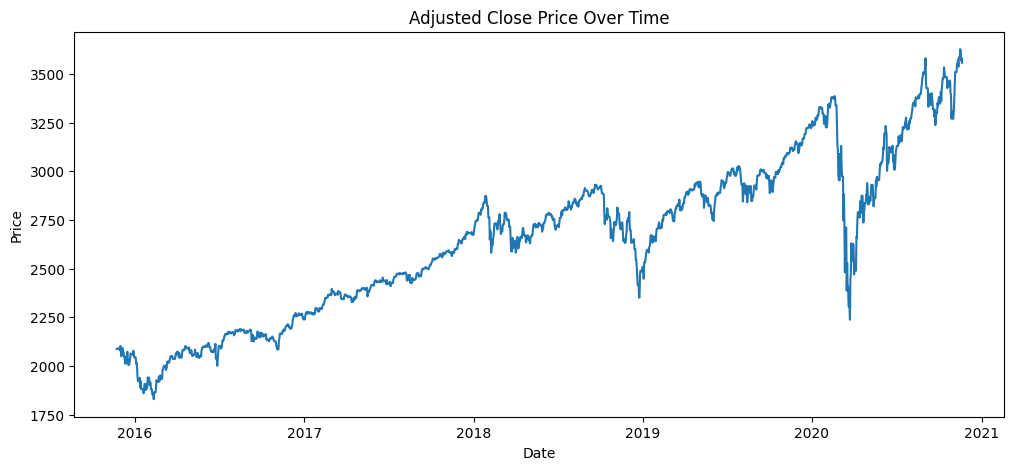

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Adj Close"])
plt.title("Adjusted Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

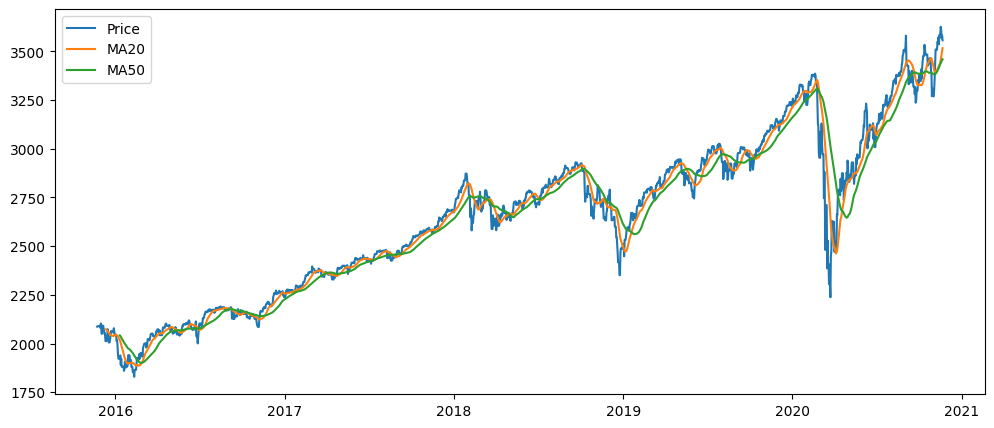

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Adj Close"], label="Price")
plt.plot(df["Date"], df["MA20"], label="MA20")
plt.plot(df["Date"], df["MA50"], label="MA50")
plt.legend()
plt.show()

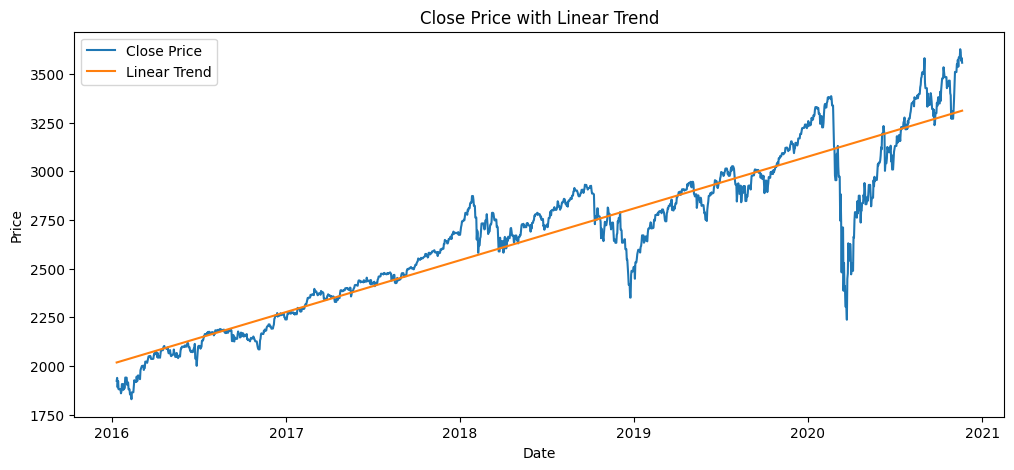

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# สร้างตัวแปรเวลาเป็นตัวเลข
df["t"] = np.arange(len(df))

X = df[["t"]]
y = df["Adj Close"]

# train linear regression
model = LinearRegression()
model.fit(X, y)

# สร้างเส้น trend
df["Trend"] = model.predict(X)

# plot
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Adj Close"], label="Close Price")
plt.plot(df["Date"], df["Trend"], label="Linear Trend(close price)")

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Close Price with Linear Trend")
plt.legend()

plt.show()

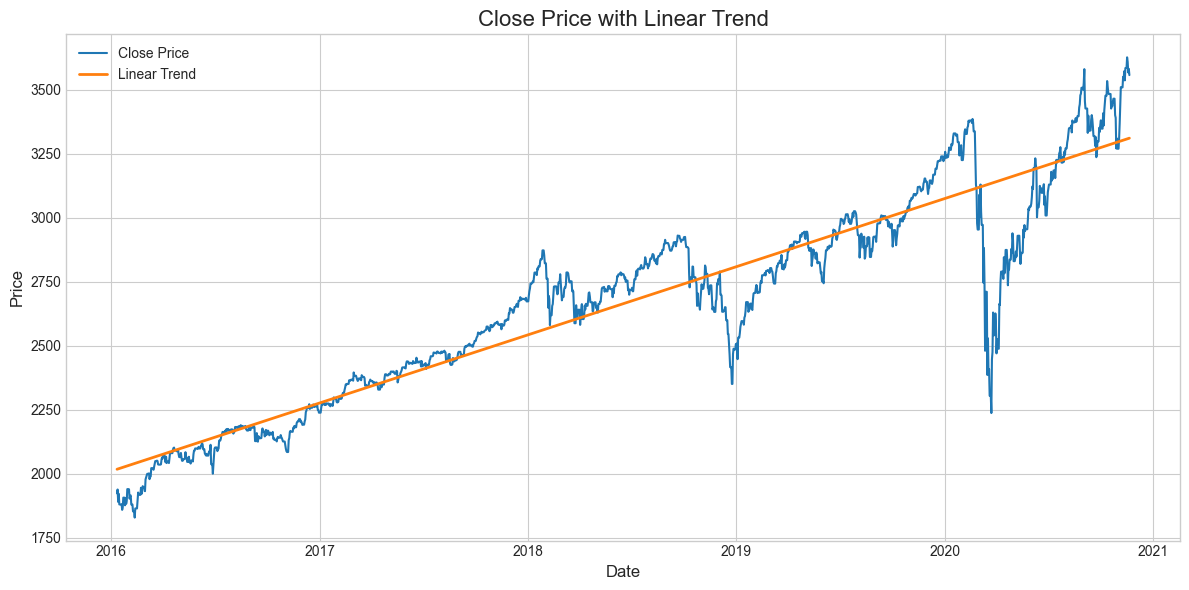

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# สร้างตัวแปรเวลา
df["t"] = np.arange(len(df))

X = df[["t"]]
y = df["Adj Close"]

# Linear Regression
model = LinearRegression()
model.fit(X, y)

# สร้างเส้นแนวโน้ม
df["Trend"] = model.predict(X)

# ใช้ style ที่ดูเหมือนงาน paper
plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Adj Close"],
         label="Close Price",
         linewidth=1.5)

plt.plot(df["Date"], df["Trend"],
         label="Linear Trend",
         linewidth=2)

plt.title("Close Price with Linear Trend", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)

plt.legend()
plt.tight_layout()

plt.show()

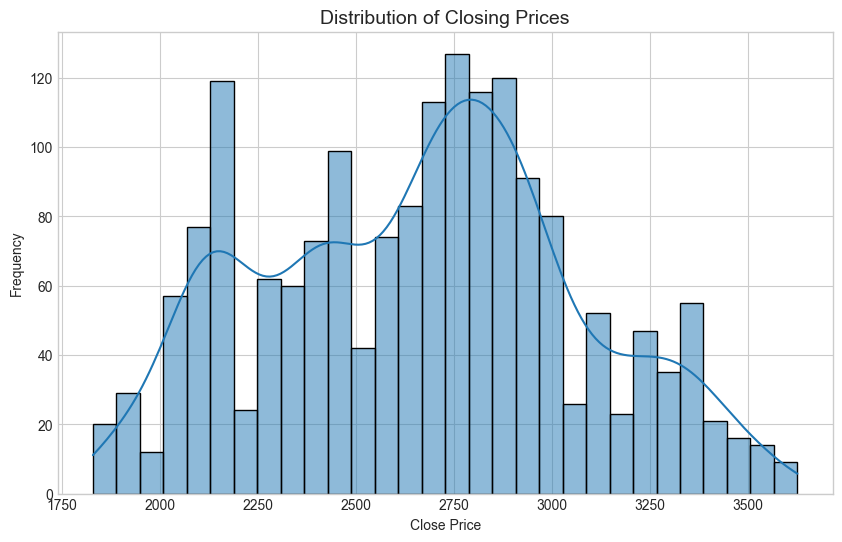

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.histplot(df["Adj Close"],
             bins=30,
             kde=True)

plt.title("Distribution of Closing Prices", fontsize=14)
plt.xlabel("Close Price")
plt.ylabel("Frequency")

plt.show()

In [5]:
df["Return"] = df["Adj Close"].pct_change()
df = df.dropna()

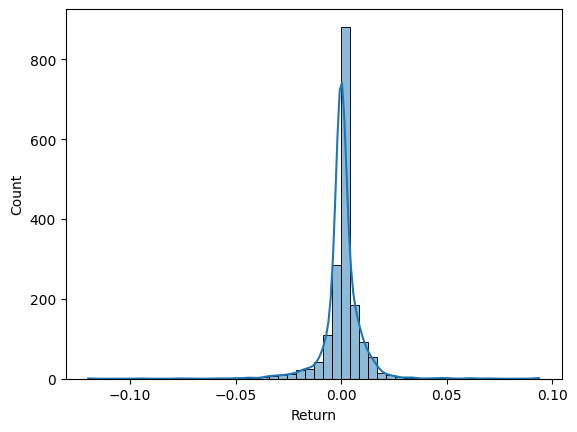

Mean: 0.00039850970271175875
Std: 0.010144159451838742
Skewness: -0.8234965965786364
Kurtosis: 30.76364296356219


In [6]:
import seaborn as sns

sns.histplot(df["Return"], bins=50, kde=True)
plt.show()

print("Mean:", df["Return"].mean())
print("Std:", df["Return"].std())
print("Skewness:", df["Return"].skew())
print("Kurtosis:", df["Return"].kurt())

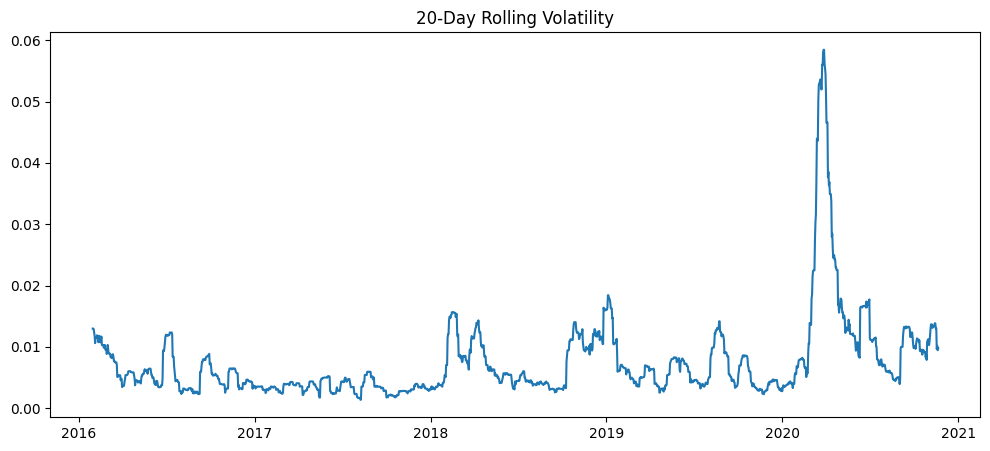

In [7]:
df["RollingVol20"] = df["Return"].rolling(20).std()

plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["RollingVol20"])
plt.title("20-Day Rolling Volatility")
plt.show()

In [8]:
Q1 = df["Return"].quantile(0.25)
Q3 = df["Return"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df["Return"] < lower) | (df["Return"] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 333


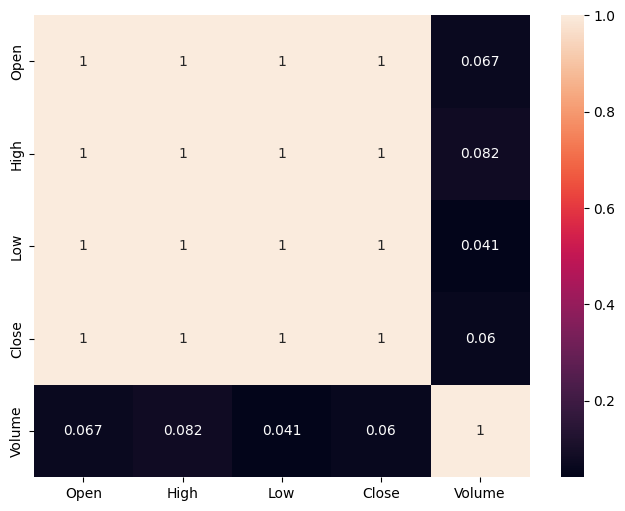

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["Open","High","Low","Close","Volume"]].corr(),
            annot=True)
plt.show()

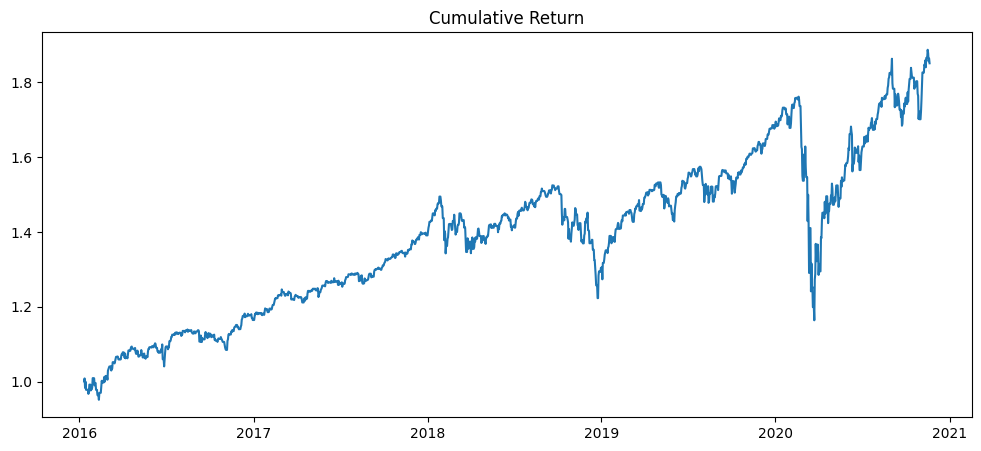

In [10]:
df["CumulativeReturn"] = (1 + df["Return"]).cumprod()

plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["CumulativeReturn"])
plt.title("Cumulative Return")
plt.show()

<Axes: >

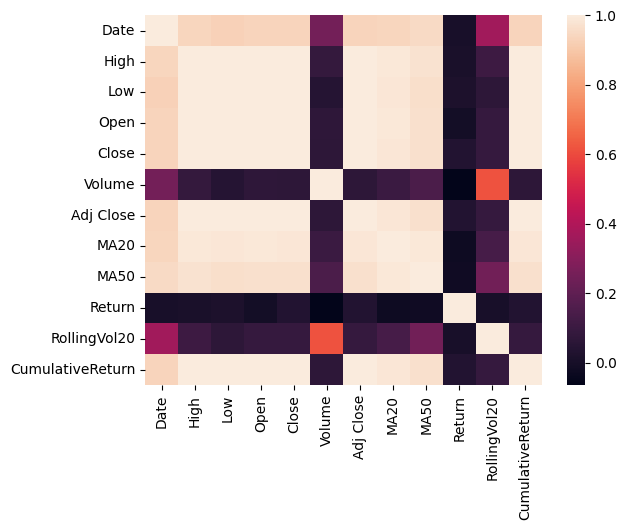

In [11]:
sns.heatmap(df.corr())

In [12]:
VaR_95 = np.percentile(df["Return"], 5)
print("VaR (95%):", VaR_95)

VaR (95%): -0.012517501011786142


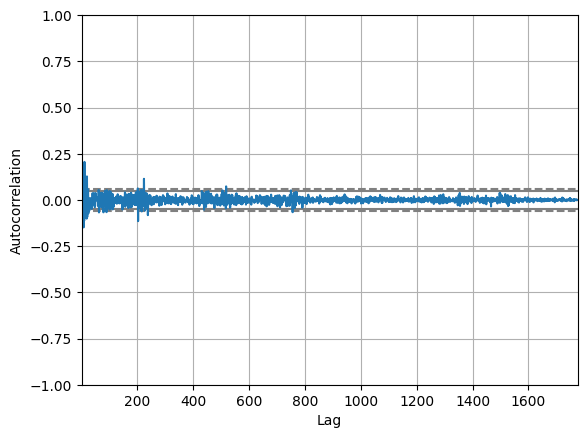

In [13]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df["Return"])
plt.show()